In [4]:
# checking whether the CiteEval quality metrics catch retracted papers

# necessary packages
import os, json, time
import pandas as pd
from dotenv import load_dotenv
from pathlib import Path
from openai import OpenAI

# setup for github push and getting OpenAI API
load_dotenv(Path('..') / '.env')
client = OpenAI(api_key = os.getenv('OPENAI_API_KEY'))

# loading the frozen benchmark (253 matched pairs)
benchmark = pd.read_csv('../data/final/benchmark_pairs.csv',
                        dtype = {'pmid': str, 'best_valid_pmid': str},
                        keep_default_na = False)
print('benchmark pairs:', len(benchmark))
print(benchmark.columns.tolist())

benchmark pairs: 253
['pmid', 'claim', 's_retracted', 'best_valid_pmid', 's_valid', 'gap', 'passes', 'reason']


In [2]:
# loading the abstract texts 

claims = pd.read_csv('../data/interim/claims_stage1.csv',
                     dtype = {'pmid': str}, keep_default_na = False)
retrieval = pd.read_pickle('../data/interim/retrieval_stage2.pkl')

# retracted abstracted, keyed by the PubMed ID
pmid_to_retracted_abs = dict(zip(claims['pmid'].astype(str), claims['abstract']))

# flatting the candidate lists into {pmid: abstract}
valid_abs = {}
for _, r in retrieval.iterrows():
    for c in r['candidates']:
        valid_abs[str(c['pmid'])] = c['abstract']

# attaching the abstract text to each benchmark pair
benchmark['retracted_abstract'] = benchmark['pmid'].map(pmid_to_retracted_abs)
benchmark['valid_abstract'] = benchmark['best_valid_pmid'].astype(str).map(valid_abs)

# sanity check to make sure every pair has both abstracts
print('missing retracted abstract:', (benchmark['retracted_abstract'] == '').sum())
print('missing valid abstract:', benchmark['valid_abstract'].isna().sum())

missing retracted abstract: 0
missing valid abstract: 0


In [3]:
# function to call gpt-4

def call_llm(prompt, model = 'gpt-4o', temperature = 0):

    # using gpt-4o and not mini here to reproduce CiteEval-Auto with the same model
    # temperature = 0 for reproducibility
    resp = client.chat.completions.create(
        model = model, temperature = temperature,
        messages = [{'role': 'user', 'content': prompt}]) 
    return resp.choices[0].message.content.strip()

In [ ]:
# CiteEval-Auto rates citation quality on a 1-5 scale.
# this prompt is reproduced from the original CiteEval paper, Appendix A.4, Table 11
# the only adaptation is the one statement = one cited passage setup (original pipeline handles multi-citation RAG responses)
# this rubric is only applied to single claim-citation pairs

CITEEVAL_PROMPT = '''You are an expert evaluating the quality of a citation for a statement in a response. Rate the citation quality on a 1-5 scale using these guidelines:

5 (Excellent): The statement is fully supported by relevant and accurate citations. There are no unnecessary, misleading, or missing citations. The citation enhances the credibility and informativeness of the statement.
4 (Good): The statement is mostly supported by accurate and relevant citations. One potentially relevant citation may be missing, or a slightly unnecessary citation may be present, but these do not significantly detract from the overall quality.
3 (Fair): The statement has some issues with citations. There might be a noticeable missing citation that somewhat weakens support, or an unnecessary or inaccurate citation that detracts from clarity.
2 (Poor): The statement has significant problems with citations. Central claims may be left unsupported, or the citation is inaccurate and undermines accuracy and credibility.
1 (Unacceptable): The statement is completely unsupported by the citation, or supported entirely by an inaccurate, irrelevant, or misleading citation. The statement is rendered misleading and unreliable.

Respond ONLY with JSON in this exact format:
{{"rating": <integer 1-5>, "reason": "<one short sentence>"}}

Statement: {claim}

Cited passage: {passage}'''

# function to rate how well the passage supports the claim (CiteEval-Auto 1-5 rating)
# returns the rating and the reason
def cite_rating(claim, passage):
    prompt = CITEEVAL_PROMPT.format(claim = claim, passage = passage)
    try:
        raw = call_llm(prompt).replace('```json', '').replace('```', '').strip()
        data = json.loads(raw)
        return int(data.get('rating', 0)), data.get('reason', '')
    except Exception as e:
        print('parse error:', e)
        return 0, ''

In [ ]:
# negative control pairs each claim with a random other paper's abstract
# ideally the metric should rate these low to show it discriminates on relevance and high scores on retracted citations aren't just everything being rated high
import random
random.seed(42)

retracted_abstracts = benchmark['retracted_abstract'].tolist()
irrelevant = []
for i in range(len(benchmark)):

    # picking a random abstract that is not this claim's own retracted abstract
    j = random.choice([k for k in range(len(benchmark)) if k != i])
    irrelevant.append(retracted_abstracts[j])
    
benchmark['irrelevant_abstract'] = irrelevant
print('assigned irrelevant control passages:', len(benchmark))

assigned irrelevant control passages: 253


In [12]:
# sanity check before scaling
# rating retracted citation vs. irrelevant control for 5 claims before scarling up
# we expected retracted to score high (4-5) and irrelevant to score low (1-2)
test = benchmark.head(5)
for _, r in test.iterrows():
    ret, ret_reason = cite_rating(r['claim'], r['retracted_abstract'])
    irr, irr_reason = cite_rating(r['claim'], r['irrelevant_abstract'])
    print(f"retracted: {ret}   irrelevant: {irr}   | {r['claim'][:55]}")

retracted: 5   irrelevant: 1   | Ectopic expression of miR-140 inhibits the migratory an
retracted: 5   irrelevant: 1   | Microsurgical strabismus correction in children results
retracted: 5   irrelevant: 1   | A higher MCA-PSV (MoM 1.7 compared to 1.5 MoM) can accu
retracted: 5   irrelevant: 1   | Stratified nursing management significantly improves nu
retracted: 5   irrelevant: 1   | Ultrasound-guided high-intensity focused ultrasound imp


In [13]:
# scaling to the full run, rating the retracted citation + irrelevant control for all 253 claims

# saving the results
results = []
for i, (_, r) in enumerate(benchmark.iterrows()):
    ret, ret_reason = cite_rating(r['claim'], r['retracted_abstract'])
    irr, irr_reason = cite_rating(r['claim'], r['irrelevant_abstract'])
    results.append({
        'pmid': r['pmid'],
        'claim': r['claim'],

        # implemented to see the retraction reason
        'reason': r['reason'],              
        'citeeval_retracted': ret,
        'citeeval_irrelevant': irr,})

    # progress bar
    if (i + 1) % 25 == 0:
        print(f'  rated {i + 1} / {len(benchmark)}')

# saving to the dataframe and then in the final results folder
findings = pd.DataFrame(results)
findings.to_csv('../data/final/findings_citeeval.csv', index = False)
print('\nsaved findings_citeeval.csv')
print('mean retracted rating:', round(findings['citeeval_retracted'].mean(), 2))
print('mean irrelevant rating:', round(findings['citeeval_irrelevant'].mean(), 2))

  rated 25 / 253
  rated 50 / 253
  rated 75 / 253
  rated 100 / 253
  rated 125 / 253
  rated 150 / 253
  rated 175 / 253
  rated 200 / 253
  rated 225 / 253
  rated 250 / 253

saved findings_citeeval.csv
mean retracted rating: 4.99
mean irrelevant rating: 1.0


In [14]:
# reloading the NLI model
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

NLI_MODEL = 'MilosKosRad/TextualEntailment_DeBERTa_preprocessedSciFACT'
tokenizer = AutoTokenizer.from_pretrained(NLI_MODEL)
model = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL)
model.eval()

# repeating the support index from the earlier run
SUPPORT_INDEX = 1 


def nli_support(passage, claim):
    #
    # NLI support probability that 'passage' supports 'claim' (0-1)
    inputs = tokenizer(passage, claim, return_tensors = 'pt', truncation = True, max_length = 512)
    with torch.no_grad():
        probs = torch.softmax(model(**inputs).logits, dim = -1)[0]
    return probs[SUPPORT_INDEX].item()

# sanity check
print('NLI model loaded')

c:\Users\kezia\Documents\retraction-aware-citeeval\.venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.74GB            

model.safetensors: downloading bytes:           |  0.00B            

NLI model loaded


c:\Users\kezia\Documents\retraction-aware-citeeval\.venv\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\kezia\.cache\huggingface\hub\models--MilosKosRad--TextualEntailment_DeBERTa_preprocessedSciFACT. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [17]:
# AIS/NLI baseline to see whether the entailment metric also rates the retracted citations as 'supported'
# used to highlight the blind spot in CiteEval's methodology
nli_scores = []
for i, (_, r) in enumerate(benchmark.iterrows()):
    nli_scores.append(nli_support(r['retracted_abstract'], r['claim']))
    if (i + 1) % 50 == 0:
        print(f'scored {i + 1} / {len(benchmark)}')

findings['nli_retracted'] = nli_scores

# updates the saved file
findings.to_csv('../data/final/findings_citeeval.csv', index = False)   

# AIS treats support >= 0.5 as a supported/valid citation
supported_frac = (findings['nli_retracted'] >= 0.5).mean()
print(f'\nmean NLI support for retracted citations: {findings['nli_retracted'].mean():.3f}')
print(f'fraction NLI rates as "supported" (>= 0.5): {supported_frac:.1%}')

scored 50 / 253
scored 100 / 253
scored 150 / 253
scored 200 / 253
scored 250 / 253

mean NLI support for retracted citations: 0.970
fraction NLI rates as "supported" (>= 0.5): 100.0%


In [ ]:
# reload the saved findings ( kernel restarted here)
findings = pd.read_csv('../data/final/findings_citeeval.csv',
                       dtype={'pmid': str}, keep_default_na=False)
print('reloaded findings:', len(findings), 'rows')
print(findings.columns.tolist())

reloaded findings: 253 rows
['pmid', 'claim', 'reason', 'citeeval_retracted', 'citeeval_irrelevant', 'nli_retracted']


In [9]:
# checking whether the paper's blind spot holds across different retraction reasons

reason_categories = {
    'Data fabrication/falsification': ['Falsification/Fabrication of Data'],
    'Data error/unreliable':          ['Error in Data', 'Unreliable Data', 'Unreliable Results and/or Conclusions'],
    'Image manipulation':             ['Manipulation of Images'],
    'Missing data':                   ['Original Data and/or Images not Provided and/or not Available'],
    'Misconduct':                     ['Misconduct by Author', 'Misconduct - Official Investigation(s) and/or Finding(s)'],}

print(f'{'Category':<32} {'n':>4} {'CiteEval':>9} {'NLI':>6} {'%rated5':>8}')

for cat, keywords in reason_categories.items():
    mask = findings['reason'].apply(lambda r: any(k in r for k in keywords))
    sub = findings[mask]
    if len(sub) == 0:
        continue

    # printing reasons
    print(f'{cat:<32} {len(sub):>4}'
          f'{sub['citeeval_retracted'].mean():>9.2f}'
          f'{sub['nli_retracted'].mean():>6.2f}'
          f'{(sub['citeeval_retracted'] == 5).mean():>7.0%}')

# overall
print(f'{'all':<32} {len(findings):>4}'
      f'{findings['citeeval_retracted'].mean():>9.2f}'
      f'{findings['nli_retracted'].mean():>6.2f}'
      f'{(findings['citeeval_retracted'] == 5).mean():>7.0%}')


Category                            n  CiteEval    NLI  %rated5
Data fabrication/falsification     26     5.00  0.97   100%
Data error/unreliable             195     4.98  0.97    99%
Image manipulation                 19     5.00  0.97   100%
Missing data                       31     5.00  0.98   100%
Misconduct                         34     5.00  0.98   100%
all                               253     4.99  0.97    99%


In [11]:
# main results 
print(f'N pairs: {len(findings)}')
print(f'CiteEval-Auto mean rating (retracted citations): {findings['citeeval_retracted'].mean():.2f} / 5')
print(f'rated 4 or 5: {(findings['citeeval_retracted'] >= 4).mean():.1%}')
print(f'rated exactly 5: {(findings['citeeval_retracted'] == 5).mean():.1%}')
print(f'CiteEval-Auto mean rating (irrelevant control): {findings['citeeval_irrelevant'].mean():.2f} / 5')
print(f'NLI/AIS mean support (retracted): {findings['nli_retracted'].mean():.3f}')
print(f"NLI rates as 'supported' (>=0.5): {(findings['nli_retracted'] >= 0.5).mean():.1%}")

N pairs: 253
CiteEval-Auto mean rating (retracted citations): 4.99 / 5
rated 4 or 5: 99.6%
rated exactly 5: 99.2%
CiteEval-Auto mean rating (irrelevant control): 1.00 / 5
NLI/AIS mean support (retracted): 0.970
NLI rates as 'supported' (>=0.5): 100.0%


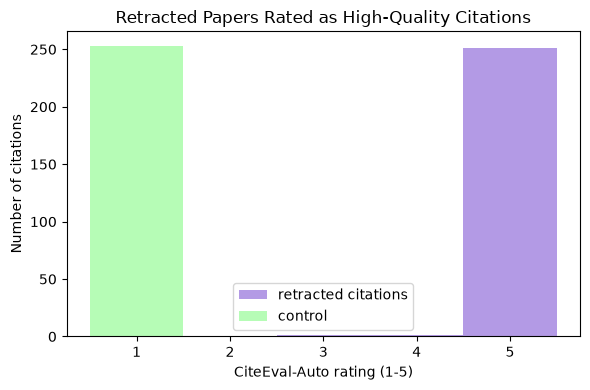

In [ ]:
# creating a visual of the results

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (6, 4))
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
ax.hist(findings['citeeval_retracted'], bins = bins, alpha = 0.7, label = 'retracted citations', color = 'mediumpurple')
ax.hist(findings['citeeval_irrelevant'], bins = bins, alpha = 0.7, label = 'control', color = 'palegreen')
ax.set_xlabel('CiteEval-Auto rating (1-5)')
ax.set_ylabel('Number of citations')
ax.set_title('Retracted Papers Rated as High-Quality Citations')
ax.set_xticks([1, 2, 3, 4, 5])
ax.legend()
plt.tight_layout()
plt.savefig('../data/final/rating_distribution.png', dpi = 150)
plt.show() 